## PROYECTO 2:ESTUDIO DE SEÑALES EEG DEL FUNCIONAMIENTO Y EL CONTROL DEL MOVIMIENTO (imaginería motora) CON ENFOQUE EN EVALUACIÓN DE SISTEMAS DE INTERFAZ CEREBRO-COMPUTADORA (BCI)
### Dataset: EEG Motor Movement/Imagery – PhysioNet / OpenNeuro ds004362
#### **Autoras:** [Luisa Fernanda Llamas Baldovino, Camila Andrea Montiel Zapata]
#### **Laboratorio de Bioseñales – UdeA 2026-1**

> **Guía de lectura:** Este notebook implementa cada etapa del flujo de procesamiento de señales para BCI de forma independiente y paso a paso.


In [2]:
# ─── Importación de librerías ───────────────────────────────────────
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import signal as sp_signal
from scipy.signal import firwin, filtfilt, hilbert
from scipy.stats import shapiro, wilcoxon, ttest_rel

import mne
mne.set_log_level('WARNING')



In [6]:
# Machine Learning
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

try:
    import antropy as ant
    ANTROPY_OK = True
except ImportError:
    ANTROPY_OK = False
    print('antropy no instalado, se usará implementación propia para SampEn')

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print('xgboost no instalado: pip install xgboost')


antropy no instalado, se usará implementación propia para SampEn


In [3]:

# ─── Parámetros globales ─────────────────────────────────────────────
SFREQ           = 160          # Hz
CANALES_INTERES = ['C3', 'Cz', 'C4']
L_FREQ, H_FREQ  = 8.0, 30.0   # Banda motora Mu + Beta
MU_BAND         = (8, 13)      # Hz
BETA_BAND       = (13, 30)     # Hz
TMIN, TMAX      = 0.0, 4.0     # Ventana de época (segundos)
M_WELCH         = 128          # Muestras por segmento Welch
S_WELCH         = M_WELCH // 2

# ─── Etiquetas de clases ─────────────────────────────────────────────
NOMBRES_CLASE = {0: 'Reposo (T0)', 1: 'Img Izq (T1)', 2: 'Img Der (T2)'}
COLORES_CLASE = {0: '#7F8C8D', 1: '#2980B9', 2: '#E74C3C'}


## **1. Configuración de rutas y búsqueda de archivos**
Solo usamos los archivos de **imaginación motora** (R04, R08, R12)
donde T1 = puño izquierdo y T2 = puño derecho.

In [7]:

RUTA_BASE = r'C:\Users\HP\Desktop\PROYECTO_EEG_BCI_1\eeg-motor-movementimagery-dataset-1.0.0\files'

N_SUJETOS        = 109
RUNS_IMAGINACION = ['R04', 'R08', 'R12']
todos_sujetos    = [f'S{i:03d}' for i in range(1, N_SUJETOS + 1)]

archivos_img = []
for sujeto in todos_sujetos:
    for run in RUNS_IMAGINACION:
        ruta = os.path.join(RUTA_BASE, sujeto, f'{sujeto}{run}.edf')
        if os.path.exists(ruta):
            archivos_img.append(ruta)

archivos_img.sort()
print(f'Archivos encontrados: {len(archivos_img)}')
print(f'Esperados: {N_SUJETOS * len(RUNS_IMAGINACION)}')
print('\nPrimeros 5:')
for a in archivos_img[:5]:
    print(' ', os.path.basename(a))


Archivos encontrados: 327
Esperados: 327

Primeros 5:
  S001R04.edf
  S001R08.edf
  S001R12.edf
  S002R04.edf
  S002R08.edf


## **2.Preprocesamiento de las señales.**


### **2.1Funciones de preprocesamiento (reutilizadas del Proyecto 1)**

Retomamos el pipeline del Proyecto 1:
- **CAR (Common Average Reference):** le resta a cada electrodo el promedio de todos.
  Esto cancela el ruido eléctrico que aparece igual en todos los canales
  (por ejemplo interferencia de red eléctrica a 60 Hz).
- **Filtro FIR pasabanda 8–30 Hz:** nos quedamos solo con las bandas Mu (8–13 Hz)
  y Beta (13–30 Hz) que son las que cambian durante la imaginación motora.
  Usamos `filtfilt` para que el filtro no cause desfase en la señal.
- **Segmentación en épocas:** cada evento (T0, T1, T2) se convierte en una
  ventana de 4 segundos que es nuestra unidad de análisis.

In [9]:
def aplicar_CAR(raw_obj):
    """
    Aplica Referencia Común a la Media (CAR).
    Elimina ruido eléctrico de modo común presente en todos los electrodos.
    x_CAR[n] = x_i[n] - (1/N) * sum_j(x_j[n])
    """
    raw_car = raw_obj.copy()
    datos   = raw_car.get_data()
    raw_car[:] = datos - datos.mean(axis=0)
    return raw_car


def aplicar_filtro_FIR(raw_car, l_freq=L_FREQ, h_freq=H_FREQ):
    """
    Filtro FIR pasabanda (8-30 Hz) de fase cero (filtfilt).
    Aísla bandas Mu y Beta eliminando artefactos de baja frecuencia y EMG.
    """
    fs     = raw_car.info['sfreq']
    delta_f = 2.0
    N_fir   = int(np.ceil(3.3 * fs / delta_f))
    if N_fir % 2 == 0:
        N_fir += 1
    b = firwin(N_fir, [l_freq, h_freq], fs=fs, window='hamming', pass_zero=False)

    raw_filt = raw_car.copy()
    datos    = raw_car.get_data()
    raw_filt[:] = filtfilt(b, [1.0], datos, axis=1)
    return raw_filt


def segmentar_epocas(raw_filt, tmin=TMIN, tmax=TMAX):
    """
    Segmenta la señal filtrada en épocas según marcadores.
    T0 = reposo, T1 = mano izquierda, T2 = mano derecha.
    Retorna dict {evento: Epochs MNE}
    """
    events, event_id = mne.events_from_annotations(raw_filt, verbose='WARNING')
    epochs_all = mne.Epochs(
        raw_filt, events, event_id=event_id,
        tmin=tmin, tmax=tmax,
        baseline=None, preload=True, verbose='WARNING'
    )
    epocas = {}
    for nombre in event_id.keys():
        try:
            epocas[str(nombre)] = epochs_all[str(nombre)]
        except:
            pass
    return epocas, event_id, epochs_all


def preprocesar_archivo(ruta_edf):
    """
    Flujo completo de preprocesamiento: carga → CAR → FIR → épocas.
    Retorna (epocas_dict, event_id) o (None, None) si falla.
    """
    try:
        raw = mne.io.read_raw_edf(ruta_edf, preload=True, verbose='WARNING')
        raw.rename_channels(lambda x: x.strip('.'))
        # Verificar que existan los canales de interés
        disponibles = set(raw.ch_names)
        if not all(c in disponibles for c in CANALES_INTERES):
            return None, None
        raw_car  = aplicar_CAR(raw)
        raw_filt = aplicar_filtro_FIR(raw_car)
        epocas, event_id, _ = segmentar_epocas(raw_filt)
        return epocas, event_id
    except Exception as e:
        return None, None

print("✔ Funciones de preprocesamiento definidas")

✔ Funciones de preprocesamiento definidas


## **3. Visualización de línea base: PSD y espectrograma**

Antes de extraer características, miramos visualmente la señal de un
sujeto de prueba para confirmar que el preprocesamiento funciona bien y para
justificar nuestras decisiones de diseño.

**¿Qué esperamos ver?**
- En la PSD: una caída de potencia en la banda Mu (8–13 Hz) en C3 o C4
  durante la imaginación motora respecto al reposo.
- En el espectrograma: esa misma caída pero en el tiempo, lo que confirma
  que los 4 segundos de ventana capturan bien el evento.

Visualizando: S001R04.edf


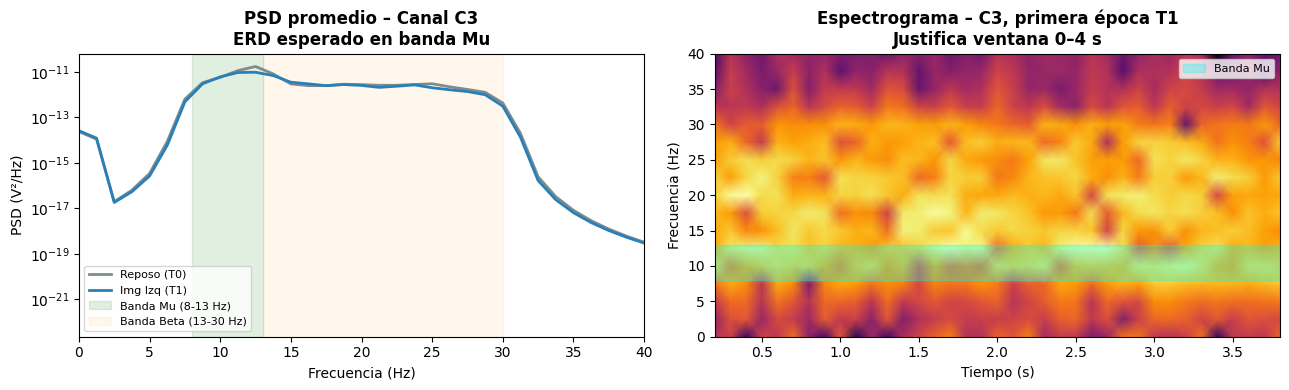

Figura guardada: figuras_P2/01_psd_espectrograma.png


In [10]:
# ── Cargar un solo archivo para visualización ────────────────────
if len(archivos_img) == 0:
    print('No se encontraron archivos. Revisar RUTA_BASE.')
else:
    ruta_prueba = archivos_img[0]   # S001R04.edf
    print(f'Visualizando: {os.path.basename(ruta_prueba)}')

    epocas_prueba, event_id_prueba = preprocesar_archivo(ruta_prueba)

    if epocas_prueba is None:
        print('No se pudo cargar el archivo.')
    else:
        # Obtener datos de C3 para T0 y T1
        idx_C3 = epocas_prueba.get(list(epocas_prueba.keys())[0]).ch_names.index('C3')

        datos_T0 = None
        datos_T1 = None

        for key in epocas_prueba:
            ep = epocas_prueba[key]
            data_c3 = ep.get_data()[:, idx_C3, :]   # (n_epocas, n_muestras)
            if 'T0' in key or key == '1':
                datos_T0 = data_c3
            elif 'T1' in key or key == '2':
                datos_T1 = data_c3

        if datos_T0 is not None and datos_T1 is not None:
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))

            # ── Panel izquierdo: PSD promedio ─────────────────────
            for datos, label, color in [
                    (datos_T0, 'Reposo (T0)',    COLORES_CLASE[0]),
                    (datos_T1, 'Img Izq (T1)',   COLORES_CLASE[1])]:

                # Calcular PSD para cada época y promediar
                psds = []
                for ep in datos:
                    f, Pxx = sp_signal.welch(ep, fs=SFREQ, nperseg=M_WELCH, noverlap=S_WELCH)
                    psds.append(Pxx)
                psd_mean = np.mean(psds, axis=0)

                axes[0].semilogy(f, psd_mean, label=label, color=color, lw=2)

            axes[0].axvspan(8, 13, alpha=0.12, color='green', label='Banda Mu (8-13 Hz)')
            axes[0].axvspan(13, 30, alpha=0.08, color='orange', label='Banda Beta (13-30 Hz)')
            axes[0].set_xlim(0, 40)
            axes[0].set_xlabel('Frecuencia (Hz)')
            axes[0].set_ylabel('PSD (V²/Hz)')
            axes[0].set_title('PSD promedio – Canal C3\nERD esperado en banda Mu', fontweight='bold')
            axes[0].legend(fontsize=8)

            # ── Panel derecho: espectrograma de la primera época T1 ──
            f_sg, t_sg, Sxx = sp_signal.spectrogram(
                datos_T1[0], fs=SFREQ, nperseg=64, noverlap=48
            )
            mascara = f_sg <= 40
            axes[1].pcolormesh(t_sg, f_sg[mascara], 10*np.log10(Sxx[mascara] + 1e-30),
                               shading='gouraud', cmap='inferno')
            axes[1].axhspan(8, 13, alpha=0.3, color='cyan', label='Banda Mu')
            axes[1].set_xlabel('Tiempo (s)')
            axes[1].set_ylabel('Frecuencia (Hz)')
            axes[1].set_title('Espectrograma – C3, primera época T1\n'
                              'Justifica ventana 0–4 s', fontweight='bold')
            axes[1].legend(fontsize=8)

            plt.tight_layout()
            plt.savefig('figuras_P2/01_psd_espectrograma.png', dpi=150, bbox_inches='tight')
            plt.show()
            print('Figura guardada: figuras_P2/01_psd_espectrograma.png')
        else:
            print('No se encontraron épocas T0/T1. Revisar nombres de anotaciones.')


In [3]:
#carga del archivos EEG